# Notebook 2 — Normalização BIO e experimento de validação

Fase final de validação do projeto de **Argumentation Mining em Community Notes BR**.
Comparamos duas estratégias de extração de spans argumentativos — **E1** (regras
simbólicas, spaCy) e **E2** (LLM) — entre si e contra um **gold humano**, sobre o
dataset consolidado pelo Notebook 1 (`notebook_preparacao_v2.ipynb`).

Cada nota recebe spans de quatro tipos: **CLAIM** (alegação refutada), **EVIDÊNCIA**
(o fato que sustenta a checagem), **FONTE** (a quem se atribui) e **QUALIFICADOR**
(modulação epistêmica).

## Como ler este notebook

O notebook tem duas partes:

- **Parte I — Camada BIO.** Carrega o dataset, projeta os spans (E1, E2 e humano) para
  uma representação **BIO** token a token (`B-TIPO` / `I-TIPO` / `O`), mantendo os spans
  com offsets como fonte primária.
- **Parte II — Experimento (proposta §4).** Mede acordo entre estratégias (§4.1),
  métricas operacionais (§4.3), caracteriza o corpus (§4.4), fidelidade ao tweet
  (§4.2), avalia contra o gold humano (§4.5), faz a leitura token-level (seqeval) e as
  análises complementares da §4.6. Fecha salvando um **dataset final** para publicação.

Cada seção traz um bloco **"Pergunta / Como ler"** antes do código e uma **"Leitura"**
logo depois, com a conclusão daquele resultado.

> **Anotadores:** o gold humano vem dos JSONs exportados pelo app de anotação. Com **1
> anotador**, ele é o gold. Com **2 anotadores**, o notebook calcula o κ inter-anotador,
> monta o **consenso** e o usa como gold — sem nenhuma outra mudança.

## Decisões metodológicas

1. **Spans com offsets são a representação primária** — base das métricas de §4.
2. **BIO é uma camada derivada e determinística:** dado o texto, os offsets e o
   tokenizador, `B-TIPO` no primeiro token de um span, `I-TIPO` nos demais, `O` fora.
3. **Tokenizador único e fixo** (`spacy.lang.pt.Portuguese`): a mesma tokenização vale
   para E1, E2 e humano, garantindo o alinhamento token a token.
4. **Política de conflito explícita** para sobreposição (só nas estratégias automáticas):
   por token, o span de maior interseção; empate → mais longo; novo empate → prioridade
   fixa de tipo. Os spans originais nunca são alterados.

As colunas de span são listas aninhadas de offsets tipados; o dataset é lido e gravado
com `pyarrow`.

## Glossário de métricas

| Métrica | O que mede | Leitura |
|---|---|---|
| **F1 estrita** | match exato de offset **e** tipo | alto = fronteiras idênticas |
| **F1 relaxada** | overlap ≥ 50% **e** tipo | alto = concordância tolerante a fronteira |
| **κ char-level** | concordância por caractere, corrigida pelo acaso | Landis & Koch: <0.2 fraca · 0.2–0.4 regular · 0.4–0.6 moderada · >0.6 substancial |
| **κ por presença** | "ambos marcaram ≥1 span deste tipo?" | robusto à granularidade de fronteira |
| **seqeval (entity)** | P/R/F1 por entidade BIO (fronteira de token + tipo) | leitura token-level por tipo |


## 0. Dependências

In [1]:
!pip -q install gdown pandas pyarrow spacy scikit-learn tqdm matplotlib

## 1. Configuração

Os IDs do Drive ficam aqui. **Para somar um anotador, basta adicionar o ID do JSON dele em `ANOTADOR_DRIVE_IDS` e re-rodar.**

In [2]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

# --- dataset (saida do Notebook 1) ---
DATASET_OVERRIDE_PATH: str | None = None
DRIVE_FILE_ID = "1uOQa49x8XCPYrydKHCkP2XREA2CdP2Mj"
DRIVE_URL = f"https://drive.google.com/uc?id={DRIVE_FILE_ID}"

# --- anotadores humanos: 1 ID do Drive por anotador (JSON exportado pelo app) ---
ANOTADOR_DRIVE_IDS = ["1Clq13JwliG-g6mEamoclZk5DeN4nds-5"]   # anotador 1; some o 2o aqui
CONSENSUS_JSON_PATH: str | None = None

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
RAW_DATASET_PATH = DATA_DIR / "dataset_anotado_final.parquet"
FINAL_DATASET_PATH = OUT_DIR / "dataset_anotado_final_com_bio.parquet"

TEXT_COL_CANDIDATES = ("text", "note_text", "summary")
SPAN_SOURCES = {"e1": "e1_spans", "e2": "e2_spans", "humano": "anotacao_humana_spans"}
LABELS = ["CLAIM", "EVIDENCIA", "FONTE", "QUALIFICADOR"]
ALLOWED_TYPES = set(LABELS)
LABEL_ALIASES = {
    "EVIDÊNCIA": "EVIDENCIA", "EVIDENCIA": "EVIDENCIA", "EVIDENCE": "EVIDENCIA",
    "SOURCE": "FONTE", "QUALIFIER": "QUALIFICADOR",
}
TYPE_PRIORITY = {"FONTE": 0, "QUALIFICADOR": 1, "CLAIM": 2, "EVIDENCIA": 3}

BIO_TOKENIZER = "spacy_pt_blank_v1"
BIO_PROJECTION_VERSION = "2.0.0"
CONFLICT_POLICY = "token_max_overlap_then_longest_then_type_priority"
print("Config OK.")

Config OK.


## 2. Carregamento do dataset

Lido com `pyarrow`, que preserva as colunas de span aninhadas.

In [3]:
def _load_dataset():
    if DATASET_OVERRIDE_PATH:
        p = Path(DATASET_OVERRIDE_PATH)
        if not p.exists():
            raise FileNotFoundError(f"DATASET_OVERRIDE_PATH nao existe: {p}")
        return p
    if not RAW_DATASET_PATH.exists():
        import gdown
        gdown.download(DRIVE_URL, str(RAW_DATASET_PATH), quiet=False)
    return RAW_DATASET_PATH

df = pd.read_parquet(_load_dataset(), engine="pyarrow")

TEXT_COL = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
if TEXT_COL is None:
    raise ValueError(f"Nenhuma coluna textual encontrada. Procurei: {TEXT_COL_CANDIDATES}")

def _n_spans(v):
    return len(v) if (v is not None and hasattr(v, "__len__")) else 0

n_e1 = int(df["e1_spans"].apply(_n_spans).gt(0).sum())
n_e2 = int(df["e2_spans"].apply(_n_spans).gt(0).sum())
print("shape:", df.shape, "| coluna texto:", TEXT_COL)
print(f"notas com spans E1: {n_e1} | E2: {n_e2}")
assert n_e1 > 0 and n_e2 > 0, "Spans E1/E2 nao carregados; leia o dataset com engine='pyarrow'."

Downloading...
From: https://drive.google.com/uc?id=1uOQa49x8XCPYrydKHCkP2XREA2CdP2Mj
To: /content/data/dataset_anotado_final.parquet
100%|██████████| 722k/722k [00:00<00:00, 20.8MB/s]


shape: (1901, 21) | coluna texto: text
notas com spans E1: 1568 | E2: 1413


### 2.1 Integridade dos spans

**Como ler:** as três fontes devem aparecer com `offsets_ruins = 0` (todos os spans caem
dentro do texto). O `humano` aparece **VAZIO** até o gold ser montado a partir do JSON do
anotador (§5).

In [4]:
def auditar(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for nome, col in SPAN_SOURCES.items():
        if col not in df.columns:
            rows.append({"fonte": nome, "coluna": col, "status": "AUSENTE"}); continue
        n = df[col].apply(_n_spans)
        tot = int(n.sum()); notas = int(n.gt(0).sum())
        ok = bad = 0
        for txt, spans in zip(df[TEXT_COL], df[col]):
            if not isinstance(txt, str): continue
            if spans is None or not hasattr(spans, "__len__") or len(spans) == 0: continue
            for s in spans:
                st, en = int(s["start"]), int(s["end"])
                if 0 <= st < en <= len(txt): ok += 1
                else: bad += 1
        rows.append({"fonte": nome, "coluna": col, "notas_com_spans": notas,
                     "spans": tot, "offsets_ok": ok, "offsets_ruins": bad,
                     "status": "OK" if tot > 0 else "VAZIO"})
    return pd.DataFrame(rows)

display(auditar(df))
if "is_meta" in df.columns:
    print("meta-notas:", int(df["is_meta"].sum()), f"({100*df['is_meta'].mean():.1f}%)")

,fonte,coluna,notas_com_spans,spans,offsets_ok,offsets_ruins,status
0,e1,e1_spans,1568,3875,3875,0,OK
1,e2,e2_spans,1413,4626,4626,0,OK
2,humano,anotacao_humana_spans,0,0,0,0,VAZIO


meta-notas: 404 (21.3%)


## 3. Anotação humana

Baixamos um JSON por anotador (a partir de `ANOTADOR_DRIVE_IDS`). Eles definem o gold:
**1 anotador** → o próprio; **2+** → consenso (§5).

In [5]:
import gdown

HUMAN_JSON_PATHS = []
for i, drive_id in enumerate(ANOTADOR_DRIVE_IDS, start=1):
    dest = DATA_DIR / f"anotador_{i}.json"
    if not dest.exists():
        gdown.download(f"https://drive.google.com/uc?id={drive_id}", str(dest), quiet=False)
    HUMAN_JSON_PATHS.append(str(dest))
print("JSONs de anotador:", HUMAN_JSON_PATHS)

Downloading...
From: https://drive.google.com/uc?id=1Clq13JwliG-g6mEamoclZk5DeN4nds-5
To: /content/data/anotador_1.json
100%|██████████| 40.0k/40.0k [00:00<00:00, 7.72MB/s]

JSONs de anotador: ['data/anotador_1.json']


In [6]:
def _load_human_json(path: str) -> tuple[str, dict[str, list[dict]]]:
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    nome = (payload.get("anotador") or {}).get("nome") or Path(path).stem
    spans = {}
    for nid, a in payload.get("anotacoes", {}).items():
        if isinstance(a, dict):
            spans[str(nid)] = [
                {"start": int(s["start"]), "end": int(s["end"]),
                 "type": LABEL_ALIASES.get(str(s["type"]).upper(), str(s["type"]).upper())}
                for s in (a.get("spans") or [])
            ]
    return nome, spans

humano_por_anotador: dict[str, dict[str, list[dict]]] = {}
for path in HUMAN_JSON_PATHS:
    nome, spans = _load_human_json(path)
    humano_por_anotador[nome] = spans
    print(f"anotador '{nome}': {len(spans)} notas, {sum(len(v) for v in spans.values())} spans")

anotador 'Davi Machado da Rocha': 60 notas, 101 spans


## 4. Definições — normalização de spans e métricas

Funções usadas em todo o notebook. As de métrica são idênticas às do Notebook 1.

In [7]:
def is_missing_value(v: Any) -> bool:
    if v is None or v is pd.NA: return True
    if isinstance(v, float) and math.isnan(v): return True
    return False

def to_builtin(v: Any) -> Any:
    return v.tolist() if hasattr(v, "tolist") else v

def coerce_spans(v: Any):
    v = to_builtin(v)
    if is_missing_value(v): return None
    if isinstance(v, str):
        s = v.strip()
        if not s or s.lower() in {"nan", "none", "null"}: return None
        v = json.loads(s)
    v = to_builtin(v)
    if isinstance(v, dict) and "spans" in v: v = v["spans"]
    if isinstance(v, tuple): v = list(v)
    if not isinstance(v, list): raise TypeError(f"spans nao e' lista: {type(v).__name__}")
    out = []
    for it in v:
        it = to_builtin(it)
        if it is None: continue
        if not isinstance(it, dict): raise TypeError(f"span nao e' dict: {type(it).__name__}")
        out.append(dict(it))
    return out

def normalize_type(raw) -> str:
    lab = LABEL_ALIASES.get(str(raw).strip().upper(), str(raw).strip().upper())
    if lab not in ALLOWED_TYPES: raise ValueError(f"Tipo invalido: {raw!r}")
    return lab

@dataclass(frozen=True)
class S:
    start: int; end: int; type: str

def _ov(a: S, b: S) -> int:
    return max(0, min(a.end, b.end) - max(a.start, b.start))

def f1_strict(gold, pred) -> float:
    g = {(s.start, s.end, s.type) for s in gold}; p = {(s.start, s.end, s.type) for s in pred}
    tp = len(g & p)
    if not tp: return 0.0 if (g or p) else 1.0
    P = tp / len(p); R = tp / len(g); return 2 * P * R / (P + R)

def f1_relaxed(gold, pred, mr: float = 0.5) -> float:
    mg, mp = set(), set()
    for i, a in enumerate(gold):
        for j, b in enumerate(pred):
            if a.type != b.type or j in mp: continue
            if _ov(a, b) / max(a.end - a.start, b.end - b.start, 1) >= mr:
                mg.add(i); mp.add(j); break
    tp = len(mg)
    if not tp: return 0.0 if (gold or pred) else 1.0
    P = tp / len(pred) if pred else 0.0; R = tp / len(gold) if gold else 0.0
    return 2 * P * R / (P + R) if (P + R) else 0.0

def _char_labels(text, spans):
    lab = ["O"] * len(text)
    for s in spans:
        for i in range(s.start, min(s.end, len(text))): lab[i] = s.type
    return lab

def cohen_kappa_chars(text, a, b) -> float:
    if not text: return 0.0
    la = _char_labels(text, a); lb = _char_labels(text, b); n = len(text)
    po = sum(1 for x, y in zip(la, lb) if x == y) / n
    cats = set(la) | set(lb)
    pe = sum((la.count(c) / n) * (lb.count(c) / n) for c in cats)
    return (po - pe) / (1 - pe) if pe < 1 else 1.0

def spans_from_cell(v):
    raw = coerce_spans(v)
    return [] if raw is None else [S(int(s["start"]), int(s["end"]),
            LABEL_ALIASES.get(str(s["type"]).upper(), str(s["type"]).upper())) for s in raw]
print("Definicoes OK.")

Definicoes OK.


## 5. Construção do gold humano (anotador único ou consenso)

O gold é montado **uma vez** e gravado em `anotacao_humana_spans`, de onde flui para a
projeção BIO e para o dataset final.

- **1 anotador:** o gold é a anotação dele.
- **2+ anotadores:** calculamos o **κ inter-anotador** (mostrado na §4.5) e o **consenso**
  por interseção exata dos spans; divergências ficam listadas para a reunião de consenso.

In [8]:
all_df_ids = set(df["noteId"].astype(str))
text_by_id = dict(zip(df["noteId"].astype(str), df[TEXT_COL]))

def _spans_from_col(series):
    out = {}
    for nid, v in zip(df["noteId"].astype(str), series):
        sp = coerce_spans(v)
        if sp is not None:
            out[nid] = [{"start": int(s["start"]), "end": int(s["end"]), "type": normalize_type(s.get("type"))} for s in sp]
    return out

anotadores = list(humano_por_anotador.items())
if not anotadores and "anotacao_humana_spans" in df.columns:
    col_gold = _spans_from_col(df["anotacao_humana_spans"])
    if col_gold:
        anotadores = [("dataset", col_gold)]
print("anotadores:", [nm for nm, _ in anotadores])

def _set(spans): return {(s["start"], s["end"], s["type"]) for s in spans}

kappa_inter_df = None; desacordos_df = None; gold = {}; gold_label = None
if CONSENSUS_JSON_PATH:
    _, gold = _load_human_json(CONSENSUS_JSON_PATH); gold_label = "consenso_resolvido"
elif len(anotadores) >= 2:
    (nA, A), (nB, B) = anotadores[0], anotadores[1]
    notes = sorted((set(A) | set(B)) & all_df_ids)
    rows = []
    for t in LABELS:
        ks = []
        for nid in notes:
            txt = text_by_id.get(nid) or ""
            if not txt: continue
            sa = [S(s["start"], s["end"], s["type"]) for s in A.get(nid, []) if s["type"] == t]
            sb = [S(s["start"], s["end"], s["type"]) for s in B.get(nid, []) if s["type"] == t]
            ks.append(cohen_kappa_chars(txt, sa, sb))
        rows.append({"tipo": t, "kappa_inter": round(np.nanmean(ks), 3) if ks else float("nan")})
    kappa_inter_df = pd.DataFrame(rows)
    des = []
    for nid in notes:
        sa, sb = A.get(nid, []), B.get(nid, [])
        gold[nid] = [{"start": x[0], "end": x[1], "type": x[2]} for x in sorted(_set(sa) & _set(sb))]
        if _set(sa) != _set(sb):
            des.append({"noteId": nid, f"so_{nA[:10]}": len(_set(sa) - _set(sb)), f"so_{nB[:10]}": len(_set(sb) - _set(sa))})
    desacordos_df = pd.DataFrame(des)
    gold_label = f"consenso({nA}+{nB})"
elif anotadores:
    gold = dict(anotadores[0][1]); gold_label = anotadores[0][0]

ids = df["noteId"].astype(str)
df["anotacao_humana_spans"] = ids.map(lambda x: gold.get(x))
df["anotacao_humana_anotador"] = ids.map(lambda x: gold_label if x in gold else None)
df["anotacao_humana_status"] = ids.map(lambda x: "selecionada_para_anotacao" if x in gold else "nao_anotada")
annotated_ids = sorted(nid for nid in gold if nid in all_df_ids)
print(f"gold = {gold_label or '—'} | {len(annotated_ids)} notas")
if len(anotadores) < 2:
    print("(κ inter-anotador e consenso requerem 2 anotadores; some o ID do 2o em ANOTADOR_DRIVE_IDS para ativá-los.)")

anotadores: ['Davi Machado da Rocha']
gold = Davi Machado da Rocha | 60 notas
(κ inter-anotador e consenso requerem 2 anotadores; some o ID do 2o em ANOTADOR_DRIVE_IDS para ativá-los.)


## 6. Tokenização fixa

Uma vez por nota, reaproveitada por E1, E2 e humano. Trata artefatos de entidade HTML.

In [9]:
from spacy.lang.pt import Portuguese
nlp = Portuguese()
HTML_ENTITY_ARTIFACT = re.compile(r"&(?:quot|amp|lt|gt|apos);?|(?:quot|amp|lt|gt|apos);")

@dataclass(frozen=True)
class Token:
    text: str; start: int; end: int

@dataclass(frozen=True)
class Span:
    type: str; text: str; start: int; end: int; source_idx: int

def split_html_entity_artifacts(token: Token) -> list[Token]:
    pieces = []; cursor = 0
    for m in HTML_ENTITY_ARTIFACT.finditer(token.text):
        if m.start() > cursor:
            pieces.append(Token(token.text[cursor:m.start()], token.start + cursor, token.start + m.start()))
        pieces.append(Token(m.group(0), token.start + m.start(), token.start + m.end()))
        cursor = m.end()
    if cursor < len(token.text):
        pieces.append(Token(token.text[cursor:], token.start + cursor, token.end))
    return pieces or [token]

def tokenize_text(text: str) -> list[Token]:
    doc = nlp(str(text)); out = []
    for tok in doc:
        out.extend(split_html_entity_artifacts(Token(tok.text, tok.idx, tok.idx + len(tok.text))))
    return out

def normalize_spans(raw_spans, text, note_id, source):
    problems = []; normalized = []
    for idx, raw in enumerate(raw_spans):
        try:
            st = int(raw.get("start")); en = int(raw.get("end")); tp = normalize_type(raw.get("type"))
            if st < 0 or en <= st or en > len(text):
                raise ValueError(f"offsets fora do texto: {st},{en},len={len(text)}")
            obs = text[st:en]; prov = raw.get("text")
            if prov is not None and str(prov) != obs:
                raise ValueError(f"texto do span != offsets")
            normalized.append(Span(tp, obs, st, en, idx))
        except Exception as exc:
            problems.append(f"{note_id}/{source}/span {idx}: {exc}")
    normalized.sort(key=lambda s: (s.start, s.end, s.type, s.source_idx))
    return normalized, problems
print("Tokenizer:", BIO_TOKENIZER)

Tokenizer: spacy_pt_blank_v1


## 7. Projeção BIO

Nível de token, com a política de conflito documentada na abertura.

In [10]:
def overlap_len(tok: Token, span: Span) -> int:
    return max(0, min(tok.end, span.end) - max(tok.start, span.start))

def choose_span_for_token(tok: Token, spans: list[Span]):
    cands = [(overlap_len(tok, s), s) for s in spans]
    cands = [(o, s) for o, s in cands if o > 0]
    if not cands: return None
    def key(item):
        ov, s = item
        return (ov, s.end - s.start, -TYPE_PRIORITY.get(s.type, 99), -s.start, -s.end)
    return max(cands, key=key)[1]

def project_spans_to_bio(tokens: list[Token], spans: list[Span]):
    labels = []; assigned = []; diag = Counter()
    for tok in tokens:
        cands = [s for s in spans if overlap_len(tok, s) > 0]
        if len(cands) > 1: diag["token_conflicts"] += 1
        chosen = choose_span_for_token(tok, cands)
        if chosen is None:
            labels.append("O"); assigned.append(None); continue
        prev_same = bool(assigned and assigned[-1] == chosen.source_idx)
        labels.append(("I-" if prev_same else "B-") + chosen.type)
        assigned.append(chosen.source_idx)
    diag["bio_spans"] = sum(1 for l in labels if l.startswith("B-"))
    return labels, dict(diag)

def labels_to_json(labels): return None if labels is None else json.dumps(labels, ensure_ascii=False)
def values_to_json(v): return json.dumps(v, ensure_ascii=False)
print("Projecao BIO OK.")

Projecao BIO OK.


## 8. Geração das colunas BIO + relatório

**Como ler:** `notes_projected` é quantas notas viraram BIO por fonte; `token_conflicts` conta tokens com sobreposição (resolvidos pela política). Tudo deve terminar com BIO alinhado aos tokens.

In [11]:
def add_bio_columns(df: pd.DataFrame, text_col: str = None):
    text_col = text_col or TEXT_COL
    out = df.copy()
    src2bio = {"e1": "e1_span_bio_json", "e2": "e2_span_bio_json", "humano": "humano_span_bio_json"}
    tok_json = []; off_json = []; bio_vals = {c: [] for c in src2bio.values()}
    report = defaultdict(Counter); problems = []
    for row_idx, row in tqdm(out.iterrows(), total=len(out), desc="BIO"):
        note_id = str(row.get("noteId", row_idx))
        text = row[text_col] if isinstance(row[text_col], str) else ("" if is_missing_value(row[text_col]) else str(row[text_col]))
        tokens = tokenize_text(text)
        tok_json.append(values_to_json([t.text for t in tokens]))
        off_json.append(values_to_json([[t.start, t.end] for t in tokens]))
        for source, span_col in SPAN_SOURCES.items():
            bio_col = src2bio[source]
            report[source]["notes_total"] += 1; report[source]["tokens_total"] += len(tokens)
            if span_col not in out.columns:
                bio_vals[bio_col].append(None); report[source]["notes_missing_column"] += 1; continue
            try:
                raw = coerce_spans(row.get(span_col))
            except Exception as exc:
                bio_vals[bio_col].append(None); report[source]["notes_with_parse_error"] += 1
                problems.append({"noteId": note_id, "source": source, "message": str(exc)}); continue
            if raw is None:
                bio_vals[bio_col].append(None); report[source]["notes_missing_spans"] += 1; continue
            report[source]["notes_available"] += 1; report[source]["raw_spans_total"] += len(raw)
            norm, probs = normalize_spans(raw, text, note_id, source)
            for m in probs: problems.append({"noteId": note_id, "source": source, "message": m})
            report[source]["invalid_spans"] += len(probs); report[source]["valid_spans_total"] += len(norm)
            labels, diag = project_spans_to_bio(tokens, norm)
            bio_vals[bio_col].append(labels_to_json(labels))
            report[source]["notes_projected"] += 1
            report[source]["token_conflicts"] += diag.get("token_conflicts", 0)
            report[source]["bio_spans_total"] += diag.get("bio_spans", 0)
    out["bio_tokens_json"] = tok_json; out["bio_offsets_json"] = off_json
    for c, vals in bio_vals.items(): out[c] = vals
    out["bio_tokenizer"] = BIO_TOKENIZER
    out["bio_projection_version"] = BIO_PROJECTION_VERSION
    out["bio_conflict_policy"] = CONFLICT_POLICY
    rep = pd.DataFrame.from_dict({k: dict(v) for k, v in report.items()}, orient="index").fillna(0).astype(int)
    rep.index.name = "source"
    return out, rep.reset_index(), pd.DataFrame(problems)

df_bio, bio_report, bio_problems = add_bio_columns(df)
display(bio_report)
print("Problemas de projecao:", 0 if bio_problems.empty else len(bio_problems))

def check_bio_lengths(d):
    bad = []
    for idx, row in d.iterrows():
        toks = json.loads(row["bio_tokens_json"])
        for col in ["e1_span_bio_json", "e2_span_bio_json", "humano_span_bio_json"]:
            v = row.get(col)
            if v is None or (isinstance(v, float) and math.isnan(v)): continue
            if len(json.loads(v)) != len(toks):
                bad.append({"noteId": row.get("noteId"), "col": col})
    return pd.DataFrame(bad)
assert check_bio_lengths(df_bio).empty, "Vetores BIO desalinhados com tokens!"
print("OK: BIO alinhado com tokens em todas as linhas.")

BIO:   0%|          | 0/1901 [00:00<?, ?it/s]

,source,notes_total,tokens_total,notes_available,raw_spans_total,invalid_spans,valid_spans_total,notes_projected,token_conflicts,bio_spans_total,notes_missing_spans
0,e1,1901,70207,1901,3875,0,3875,1901,2958,3309,0
1,e2,1901,70207,1901,4626,0,4626,1901,11,4625,0
2,humano,1901,70207,60,101,0,101,60,0,101,1841


Problemas de projecao: 0
OK: BIO alinhado com tokens em todas as linhas.


---
# Parte II — Experimento (proposta §4)

## 9. Reprodução das métricas do Notebook 1

**Pergunta:** este notebook parte exatamente dos mesmos spans que o Notebook 1?
**Como ler:** recalculamos `f1_strict`/`f1_relaxed`/`kappa` (E1×E2) e comparamos com as
colunas gravadas. **`max_diff ≈ 0` é o selo de auditoria** — confirma a continuidade.

In [12]:
def _row_metrics(df):
    fs, fr, kp = [], [], []
    for _, r in df.iterrows():
        e1 = spans_from_cell(r["e1_spans"]); e2 = spans_from_cell(r["e2_spans"]); t = r[TEXT_COL] or ""
        fs.append(f1_strict(e1, e2)); fr.append(f1_relaxed(e1, e2)); kp.append(cohen_kappa_chars(t, e1, e2))
    return np.array(fs), np.array(fr), np.array(kp)

if {"f1_strict", "f1_relaxed", "kappa"} <= set(df.columns):
    fs, fr, kp = _row_metrics(df)
    chk = pd.DataFrame({"metrica": ["f1_strict", "f1_relaxed", "kappa"],
        "max_diff": [np.abs(fs - df["f1_strict"].values).max(),
                     np.abs(fr - df["f1_relaxed"].values).max(),
                     np.abs(kp - df["kappa"].values).max()]})
    display(chk)
    assert chk["max_diff"].max() < 1e-3, "Reproducao falhou."
    print("OK: metricas reproduzidas (max_diff < 1e-3).")
else:
    print("Colunas f1/kappa ausentes; pulando cross-check.")

,metrica,max_diff
0,f1_strict,0.0
1,f1_relaxed,0.0
2,kappa,0.0


OK: metricas reproduzidas (max_diff < 1e-3).


## 10. §4.1 — Acordo inter-estratégia (E1×E2) em 3 cortes

**Pergunta:** as duas estratégias enxergam a mesma argumentação? E onde divergem?
**Cortes:** **A** todas as notas · **B** sem meta-notas · **C** só onde ambas produziram spans.
**Como ler:** na κ por presença, valor alto = concordam que aquele tipo existe; se o acordo
**cai** de A→C, divergem mais justamente quando há material argumentativo real.

In [13]:
def _pres(spans, t): return any(s.type == t for s in spans)
def kappa_presence(a: np.ndarray, b: np.ndarray) -> float:
    n = len(a)
    if n == 0: return float("nan")
    po = (a == b).mean(); pa, pb = a.sum() / n, b.sum() / n
    pe = pa * pb + (1 - pa) * (1 - pb)
    return (po - pe) / (1 - pe) if pe < 1 else 0.0

work = df.copy()
work["_e1"] = work["e1_spans"].apply(spans_from_cell)
work["_e2"] = work["e2_spans"].apply(spans_from_cell)
work["_n1"] = work["_e1"].apply(len); work["_n2"] = work["_e2"].apply(len)
work["_fs"] = [f1_strict(a, b) for a, b in zip(work["_e1"], work["_e2"])]
work["_fr"] = [f1_relaxed(a, b) for a, b in zip(work["_e1"], work["_e2"])]
work["_kp"] = [cohen_kappa_chars(t or "", a, b) for t, a, b in zip(work[TEXT_COL], work["_e1"], work["_e2"])]

cortes = {
    "A_completo": work,
    "B_sem_meta": work[~work["is_meta"]] if "is_meta" in work.columns else work,
    "C_ambos_marcaram": work[(work["_n1"] > 0) & (work["_n2"] > 0)],
}
resumo = pd.DataFrame([
    {"corte": k, "n": len(d), "F1_estrita": round(d["_fs"].mean(), 3),
     "F1_relaxada": round(d["_fr"].mean(), 3), "kappa_char": round(d["_kp"].mean(), 3)}
    for k, d in cortes.items()])
print("§4.1 — medias por corte"); display(resumo)

pres_rows = []
for k, d in cortes.items():
    for t in LABELS:
        a = d["_e1"].apply(lambda s: _pres(s, t)).values.astype(int)
        b = d["_e2"].apply(lambda s: _pres(s, t)).values.astype(int)
        pres_rows.append({"corte": k, "tipo": t, "cob_E1_%": round(100 * a.mean(), 1),
                          "cob_E2_%": round(100 * b.mean(), 1), "kappa_presenca": round(kappa_presence(a, b), 3)})
pres_df = pd.DataFrame(pres_rows)
print("§4.1 — κ por presença de tipo")
display(pres_df.pivot(index="tipo", columns="corte", values="kappa_presenca").reindex(LABELS))

§4.1 — medias por corte


,corte,n,F1_estrita,F1_relaxada,kappa_char
0,A_completo,1901,0.307,0.459,0.366
1,B_sem_meta,1497,0.272,0.446,0.338
2,C_ambos_marcaram,1331,0.250,0.466,0.334


§4.1 — κ por presença de tipo


corte,A_completo,B_sem_meta,C_ambos_marcaram
tipo,,,
CLAIM,0.100,0.079,0.060
EVIDENCIA,0.277,0.214,0.103
FONTE,0.629,0.537,0.447
QUALIFICADOR,0.036,0.046,0.044


**Leitura.** As duas estratégias concordam pouco, e o acordo **cai** do corte A para o
C: quando ambas de fato produzem spans (há material argumentativo), elas divergem **mais**.
Na κ por presença, o acordo se concentra em **FONTE** — um sinal lexical, "segundo…", URLs —
e quase some em **CLAIM** e **QUALIFICADOR**, que exigem interpretação. É a pergunta central
da proposta respondida com evidência: *paradigmas distintos divergem onde a argumentação
deixa de ser superficial*. (Ressalva: a κ char-level é influenciada pela alta prevalência de
`O`; leia-a junto da F1 relaxada e da κ por presença.)

## 11. §4.3 — Métricas operacionais

**Como ler:** a **cobertura** revela o perfil de cada estratégia; os **níveis de alinhamento do E2** medem o quanto os spans do LLM casam com o texto (`failed < 3%` é o critério interno); a **latência** mostra o custo de cada abordagem.

In [14]:
cov_rows = [{"tipo": t,
    "cob_E1_%": round(100 * work["_e1"].apply(lambda s: _pres(s, t)).mean(), 1),
    "cob_E2_%": round(100 * work["_e2"].apply(lambda s: _pres(s, t)).mean(), 1)} for t in LABELS]
cobertura_df = pd.DataFrame(cov_rows)
print("Cobertura por tipo"); display(cobertura_df)

if "e2_align_levels" in df.columns:
    al = pd.json_normalize(df["e2_align_levels"].dropna())
    tot = al.sum(); pct = (100 * tot / tot.sum()).round(2)
    print("Niveis de alinhamento E2 (%):"); display(pct.to_frame("pct"))
    if "failed" in pct: print("failed < 3%? ", bool(pct["failed"] < 3))

for col, nome in [("e1_ms", "E1"), ("e2_ms", "E2")]:
    if col in df.columns:
        s = df[col].dropna()
        print(f"{nome}: mediana={s.median():.1f}ms p95={s.quantile(.95):.1f}ms p99={s.quantile(.99):.1f}ms total={s.sum()/1000:.1f}s")

Cobertura por tipo


,tipo,cob_E1_%,cob_E2_%
0,CLAIM,26.0,60.2
1,EVIDENCIA,37.7,60.7
2,FONTE,72.0,56.5
3,QUALIFICADOR,0.6,4.1


Niveis de alinhamento E2 (%):


,pct
exact,98.52
failed,1.03
normalized,0.21
regex,0.24
unicode_normalized,0.00


failed < 3%?  True
E1: mediana=1.9ms p95=8.9ms p99=20.4ms total=5.8s
E2: mediana=4617.4ms p95=10839.9ms p99=14678.5ms total=9833.9s


**Leitura.** Os perfis se separam: o **E1** é forte em **FONTE** e essencialmente
gratuito (latência de milissegundos); o **E2** é mais **balanceado** entre os tipos, ao
custo de segundos por nota — ordens de grandeza mais caro. É o trade-off simbólico×neural:
regras baratas e boas no padrão lexical, rasas no resto; LLM caro e abrangente. O alinhamento
dos spans do E2 ao texto fica bem acima do critério interno (`failed < 3%`).

## 12. §4.4 — Caracterização do corpus (meta-notas)

**Como ler:** a fração de meta-notas (que comentam o sistema em vez de argumentar) é um achado descritivo do gênero; o prefixo `NNN` ("não necessita nota") domina.

In [15]:
if "is_meta" in df.columns:
    print(f"meta-notas: {int(df['is_meta'].sum())} de {len(df)} ({100*df['is_meta'].mean():.1f}%)")
    if "meta_reason" in df.columns:
        display(df.loc[df["is_meta"], "meta_reason"].value_counts().to_frame("n"))

meta-notas: 404 de 1901 (21.3%)


,n
meta_reason,
prefixo_NNN,334
muito_curta,48
nao_necessita_nota,16
piada_satira_opiniao,5
uso_indevido_nota,1


**Leitura.** Cerca de **um quinto** do corpus são meta-notas — textos que comentam o
próprio Community Notes em vez de checar fatos, sobretudo com prefixo `NNN`. É a camada
metalinguística do gênero destacada na proposta, e a justificativa do corte **B** da §4.1.

## 13. §4.2 — Fidelidade da CLAIM ao tweet (TF-IDF)

**Pergunta:** o CLAIM que cada estratégia extrai realmente "vem" do tweet original?
**Como ler:** cosseno TF-IDF entre o texto do CLAIM e o tweet. TF-IDF é lexical (não capta
paráfrase), então os valores absolutos são baixos; **o sinal é a diferença E1×E2**.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def claim_text(spans, text):
    return " ".join(text[s.start:s.end] for s in spans if s.type == "CLAIM")

def fidelidade(col):
    sub = work[work["tweet_text"].notna() & (work["tweet_text"].astype(str).str.len() > 0)]
    vals = []
    for _, r in sub.iterrows():
        ct = claim_text(r[col], r[TEXT_COL] or ""); tw = str(r["tweet_text"])
        if not ct.strip(): continue
        try:
            m = TfidfVectorizer().fit_transform([ct, tw])
            vals.append(float(cosine_similarity(m[0], m[1])[0][0]))
        except Exception:
            continue
    return np.array(vals)

if "tweet_text" in work.columns:
    fe1, fe2 = fidelidade("_e1"), fidelidade("_e2")
    display(pd.DataFrame({"estrategia": ["E1", "E2"], "n_claims": [len(fe1), len(fe2)],
        "cosseno_medio": [round(fe1.mean(), 3) if len(fe1) else float("nan"),
                          round(fe2.mean(), 3) if len(fe2) else float("nan")],
        "cosseno_mediano": [round(np.median(fe1), 3) if len(fe1) else float("nan"),
                            round(np.median(fe2), 3) if len(fe2) else float("nan")]}))

,estrategia,n_claims,cosseno_medio,cosseno_mediano
0,E1,494,0.060,0.038
1,E2,1145,0.081,0.057


**Leitura.** Os valores absolutos são baixos, como esperado de uma métrica lexical. O
sinal está na **diferença**: o CLAIM extraído pelo **E2 ancora um pouco mais no tweet** que o
do E1 — e o E2 extrai mais CLAIMs. Coerente com o E2 estar mais próximo do humano.

## 14. §4.5 — Avaliação contra o gold humano

**Pergunta:** qual estratégia se aproxima mais do julgamento humano?
**Como ler:** com 2 anotadores, o **κ inter-anotador** mede a concordância humana e as
divergências viram pauta de consenso. Depois, **E1/E2 vs gold**: F1 estrita (fronteira exata)
e relaxada (overlap) — quanto maior, mais perto do humano.

In [17]:
if kappa_inter_df is not None:
    print("κ inter-anotador (char-level por tipo):"); display(kappa_inter_df)
    if desacordos_df is not None and not desacordos_df.empty:
        print(f"Notas com desacordo a resolver no consenso: {len(desacordos_df)}")
        display(desacordos_df.head(20))
else:
    print("1 anotador: gold = anotação única (κ inter-anotador aparece com 2 anotadores).")

def vs_gold(col):
    fs, fr = [], []
    for nid in annotated_ids:
        g = [S(s["start"], s["end"], s["type"]) for s in gold[nid]]
        p = spans_from_cell(df.loc[df["noteId"].astype(str) == nid, col].iloc[0])
        fs.append(f1_strict(g, p)); fr.append(f1_relaxed(g, p))
    return (np.mean(fs) if fs else float("nan"), np.mean(fr) if fr else float("nan"), len(fs))

vsgold_df = None
if gold:
    rows = []
    for col, nome in [("e1_spans", "E1"), ("e2_spans", "E2")]:
        f_s, f_r, n = vs_gold(col)
        rows.append({"estrategia": nome, "n_notas": n, "F1_estrita": round(f_s, 3), "F1_relaxada": round(f_r, 3)})
    vsgold_df = pd.DataFrame(rows)
    print(f"E1/E2 vs gold humano ({gold_label}, offset):"); display(vsgold_df)

1 anotador: gold = anotação única (κ inter-anotador aparece com 2 anotadores).
E1/E2 vs gold humano (Davi Machado da Rocha, offset):


,estrategia,n_notas,F1_estrita,F1_relaxada
0,E1,60,0.017,0.136
1,E2,60,0.340,0.466


**Leitura.** O **LLM (E2) se aproxima nitidamente mais do julgamento humano** que as
regras (E1), tanto na F1 estrita quanto na relaxada. O E1, a nível de fronteira, quase não
reproduz a anotação humana — seu valor está na cobertura de FONTE e no custo, não na precisão
fina. (Ressalvas: **QUALIFICADOR é raríssimo** na amostra, então métrica perto de zero ali é
falta de exemplos, não fracasso; e com **um anotador** o gold é referência única — o κ
inter-anotador e o consenso entram automaticamente com a 2ª anotação.)

## 15. Gráficos

Leitura visual da cobertura por tipo (perfil das estratégias) e do desempenho vs gold.

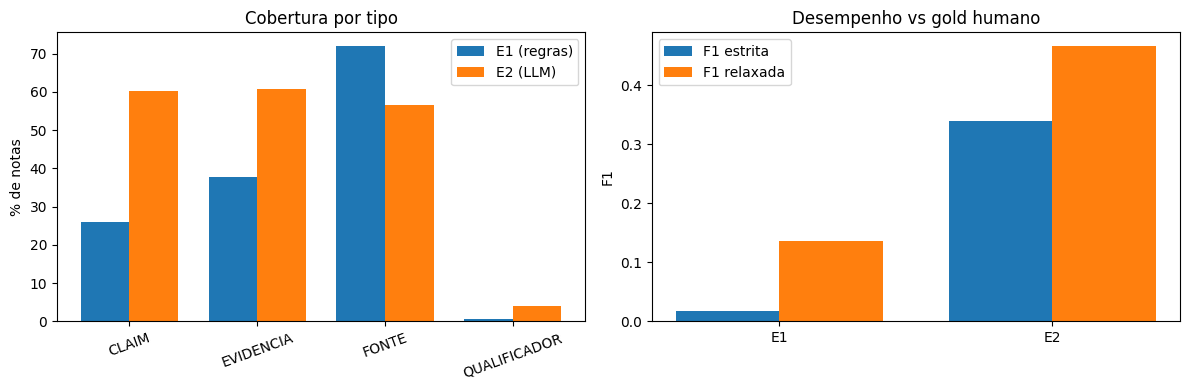

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(LABELS)); w = 0.38
axes[0].bar(x - w/2, cobertura_df["cob_E1_%"], w, label="E1 (regras)")
axes[0].bar(x + w/2, cobertura_df["cob_E2_%"], w, label="E2 (LLM)")
axes[0].set_xticks(x); axes[0].set_xticklabels(LABELS, rotation=20)
axes[0].set_ylabel("% de notas"); axes[0].set_title("Cobertura por tipo"); axes[0].legend()

if vsgold_df is not None:
    xx = np.arange(len(vsgold_df))
    axes[1].bar(xx - w/2, vsgold_df["F1_estrita"], w, label="F1 estrita")
    axes[1].bar(xx + w/2, vsgold_df["F1_relaxada"], w, label="F1 relaxada")
    axes[1].set_xticks(xx); axes[1].set_xticklabels(vsgold_df["estrategia"])
    axes[1].set_ylabel("F1"); axes[1].set_title("Desempenho vs gold humano"); axes[1].legend()
else:
    axes[1].axis("off"); axes[1].set_title("vs gold: requer anotação humana")
plt.tight_layout(); plt.show()

## 16. Avaliação token-level (seqeval)

**Como ler:** P/R/F1 por entidade BIO (fronteira de token **e** tipo). Na **matriz de
confusão** (linha = humano, coluna = E2), valores fora da diagonal em `O→TIPO` indicam
**super-extração**; `TIPO→O` indica **omissão**.

In [19]:
def bio_entities(labels):
    ents = set(); i = 0
    while i < len(labels):
        if labels[i].startswith("B-"):
            t = labels[i][2:]; j = i + 1
            while j < len(labels) and labels[j] == f"I-{t}": j += 1
            ents.add((i, j, t)); i = j
        else: i += 1
    return ents

def entity_prf(gold_lists, pred_lists):
    tp = fp = fn = 0; per = {t: [0, 0, 0] for t in LABELS}
    for g, p in zip(gold_lists, pred_lists):
        ge, pe = bio_entities(g), bio_entities(p)
        tp += len(ge & pe); fp += len(pe - ge); fn += len(ge - pe)
        for t in LABELS:
            gt = {e for e in ge if e[2] == t}; pt = {e for e in pe if e[2] == t}
            per[t][0] += len(gt & pt); per[t][1] += len(pt - gt); per[t][2] += len(gt - pt)
    def prf(tp, fp, fn):
        P = tp / (tp + fp) if tp + fp else 0.0; R = tp / (tp + fn) if tp + fn else 0.0
        return P, R, (2 * P * R / (P + R) if P + R else 0.0)
    P, R, F = prf(tp, fp, fn)
    rows = [{"escopo": "micro", "P": round(P, 3), "R": round(R, 3), "F1": round(F, 3)}]
    for t in LABELS:
        p, r, f = prf(*per[t]); rows.append({"escopo": t, "P": round(p, 3), "R": round(r, 3), "F1": round(f, 3)})
    return pd.DataFrame(rows)

pairs = [(json.loads(a), json.loads(b)) for a, b in zip(df_bio["e1_span_bio_json"], df_bio["e2_span_bio_json"])
         if isinstance(a, str) and isinstance(b, str)]
if pairs:
    print("Token-level (entity) — E1×E2, corpus inteiro:")
    display(entity_prf([x[0] for x in pairs], [x[1] for x in pairs]))

hum_mask = df_bio["humano_span_bio_json"].notna()
if hum_mask.any():
    sub = df_bio[hum_mask]
    h = [json.loads(v) for v in sub["humano_span_bio_json"]]
    e1 = [json.loads(v) for v in sub["e1_span_bio_json"]]
    e2 = [json.loads(v) for v in sub["e2_span_bio_json"]]
    print("Token-level (entity) — E1 vs humano:"); display(entity_prf(h, e1))
    print("Token-level (entity) — E2 vs humano:"); display(entity_prf(h, e2))
    cats = ["O"] + LABELS
    conf = pd.DataFrame(0, index=cats, columns=cats)
    for hl, el in zip(h, e2):
        for a, b in zip(hl, el): conf.loc[a.split("-")[-1], b.split("-")[-1]] += 1
    print("Matriz de confusao por token (linha=humano, coluna=E2):"); display(conf)

Token-level (entity) — E1×E2, corpus inteiro:


,escopo,P,R,F1
0,micro,0.181,0.253,0.211
1,CLAIM,0.015,0.045,0.023
2,EVIDENCIA,0.009,0.018,0.012
3,FONTE,0.522,0.404,0.456
4,QUALIFICADOR,0.013,0.100,0.023


Token-level (entity) — E1 vs humano:


,escopo,P,R,F1
0,micro,0.011,0.020,0.014
1,CLAIM,0.000,0.000,0.000
2,EVIDENCIA,0.051,0.036,0.043
3,FONTE,0.000,0.000,0.000
4,QUALIFICADOR,0.000,0.000,0.000


Token-level (entity) — E2 vs humano:


,escopo,P,R,F1
0,micro,0.293,0.485,0.366
1,CLAIM,0.321,0.447,0.374
2,EVIDENCIA,0.375,0.491,0.425
3,FONTE,0.132,0.714,0.222
4,QUALIFICADOR,0.000,0.000,0.000


Matriz de confusao por token (linha=humano, coluna=E2):


,O,CLAIM,EVIDENCIA,FONTE,QUALIFICADOR
O,1082,203,241,50,18
CLAIM,71,259,46,0,0
EVIDENCIA,196,18,661,8,0
FONTE,3,0,0,43,0
QUALIFICADOR,4,0,0,0,0


**Leitura.** A matriz de confusão revela *como* o E2 erra: ele **super-extrai** — marca
como CLAIM/EVIDÊNCIA trechos que o humano deixou em `O` — e às vezes **omite evidência**
(EVIDÊNCIA→`O`). As fronteiras de **FONTE** são imprecisas (recall alto, precisão baixa: pega
a fonte mas erra os limites). **QUALIFICADOR** tem exemplos demais escassos para conclusões.

## 17. §4.6 — Análises complementares

A **triangulação** (17.1) fecha a parte quantitativa. As demais análises complementares da
§4.6 — **assinatura léxica por tipo** (Dunning), **lente de entidade × papel** e o **perfil
granular por entidade** (palavras distintivas por classe gramatical) — são exploratórias e
ficam melhor navegáveis: migraram para o **explorador interativo** (17.2), construído sobre a
camada BIO e o corpus de entidades.

### 17.1 Triangulação

**Como ler:** comparamos o acordo humano×estratégia (κ char-level) com a fidelidade TF-IDF
(§4.2). Se a estratégia mais próxima do humano também for a mais fiel ao tweet, a métrica
automática está calibrada com o julgamento humano.

In [20]:
if gold:
    rows = []
    for col, nome in [("e1_spans", "E1"), ("e2_spans", "E2")]:
        ks = []
        for nid in annotated_ids:
            txt = text_by_id.get(nid) or ""
            g = [S(s["start"], s["end"], s["type"]) for s in gold[nid]]
            p = spans_from_cell(df.loc[df["noteId"].astype(str) == nid, col].iloc[0])
            if txt: ks.append(cohen_kappa_chars(txt, g, p))
        rows.append({"estrategia": nome, "kappa_vs_gold": round(np.nanmean(ks), 3) if ks else float("nan")})
    display(pd.DataFrame(rows))

,estrategia,kappa_vs_gold
0,E1,-0.003
1,E2,0.428


**Leitura.** A estratégia mais próxima do humano (κ vs gold) é a mesma que ancora mais o
CLAIM no tweet (§4.2): os dois sinais apontam na mesma direção, o que dá alguma validade
convergente à métrica TF-IDF como proxy barato do julgamento humano.

### 17.2 Explorador interativo

As análises léxicas e de entidade são mais ricas navegáveis. O explorador estático — spans
coloridos por nota (com o raciocínio do E2), **perfil por entidade** com palavras distintivas
por classe gramatical, **lente entidade × papel** e **painel de achados** — está publicado no
Netlify e embutido abaixo. Código e build em `explorador-argumentos/`.

In [ ]:
from IPython.display import IFrame
IFrame("https://explorador-argumentos.netlify.app/", width="100%", height=720)

## 18. Camada sintática (POS · lema · dependência)

O Notebook 1 já rodou o parser completo (`pt_core_news_md`) para extrair os spans do E1 — mas
**só os spans foram persistidos**; o parse (POS, lema, relação de dependência) foi intermediário
e descartado. Aqui re-rodamos o **mesmo modelo** e **salvamos** essa camada no dataset final, para
análises sintáticas reprodutíveis — assinatura léxica lematizada e a leitura de **agência
sujeito × objeto** (via `deprel`) — sem precisar re-taggear.

In [ ]:
import spacy
try:
    nlp_full = spacy.load("pt_core_news_md")
except OSError:
    from spacy.cli import download as _spacy_dl
    _spacy_dl("pt_core_news_md"); nlp_full = spacy.load("pt_core_news_md")

def _parse_nota(doc):
    return [{"i": t.i, "form": t.text, "lemma": t.lemma_, "upos": t.pos_,
             "deprel": t.dep_, "head": t.head.i, "start": t.idx, "end": t.idx + len(t.text)}
            for t in doc if not t.is_space]

_sint = []
for doc in tqdm(nlp_full.pipe(df_bio[TEXT_COL].fillna("").astype(str), batch_size=64),
                total=len(df_bio), desc="Sintaxe (pt_core_news_md)"):
    _sint.append(json.dumps(_parse_nota(doc), ensure_ascii=False))
df_bio["sintaxe_json"] = _sint
print("sintaxe_json em", int(df_bio["sintaxe_json"].notna().sum()),
      "notas — POS/lema/deprel persistidos no dataset final")

## 19. Dataset final e artefatos

O `df_bio` carrega **tudo**: spans E1/E2, gold humano (consenso, quando há 2 anotadores), as
camadas BIO das três fontes, a **camada sintática** (`sintaxe_json`: POS/lema/dependência, §18),
as métricas e os metadados de reprodução. Salvamos o parquet final + um `sintaxe.json` e CSVs
auxiliares. É o pacote para subir no repositório do curso.

In [23]:
df_bio.to_parquet(FINAL_DATASET_PATH, engine="pyarrow", index=False)
bio_report.to_csv(OUT_DIR / "relatorio_bio_projection.csv", index=False)
if not bio_problems.empty:
    bio_problems.to_csv(OUT_DIR / "problemas_bio_projection.csv", index=False)
resumo.to_csv(OUT_DIR / "metricas_4_1_cortes.csv", index=False)
pres_df.to_csv(OUT_DIR / "metricas_4_1_presenca.csv", index=False)
if vsgold_df is not None:
    vsgold_df.to_csv(OUT_DIR / "metricas_4_5_vs_gold.csv", index=False)
if kappa_inter_df is not None:
    kappa_inter_df.to_csv(OUT_DIR / "kappa_inter_anotador.csv", index=False)
if desacordos_df is not None and not desacordos_df.empty:
    desacordos_df.to_csv(OUT_DIR / "desacordos_para_consenso.csv", index=False)
if "sintaxe_json" in df_bio.columns:
    sint_map = {str(nid): json.loads(s) for nid, s in zip(df_bio["noteId"], df_bio["sintaxe_json"]) if isinstance(s, str)}
    (OUT_DIR / "sintaxe.json").write_text(json.dumps(sint_map, ensure_ascii=False), encoding="utf-8")
    print("sintaxe.json:", len(sint_map), "notas (POS/lema/deprel)")

print("Dataset final:", FINAL_DATASET_PATH, "| linhas:", len(df_bio))
print("gold humano:", gold_label, "|", len(annotated_ids), "notas")

Dataset final: outputs/dataset_anotado_final_com_bio.parquet | linhas: 1901
gold humano: Davi Machado da Rocha | 60 notas


## 20. Download no Colab (opcional)

In [ ]:
# from google.colab import files
# files.download(str(FINAL_DATASET_PATH))

## Síntese final

As leituras por seção convergem para um quadro único: **E1 e E2 são dois paradigmas que
divergem onde a argumentação exige interpretação** (CLAIM, QUALIFICADOR) e convergem no que é
lexical (FONTE). O **E2 (LLM) alinha-se mais ao gold humano**; o **E1 (regras) compensa em
cobertura de FONTE e em custo** (ordens de grandeza mais rápido). As análises complementares
da §4.6 — assinatura léxica por tipo, lente de entidade × papel e perfil por entidade — vivem
no **explorador interativo** (§17.2) e detalham esse quadro: cada tipo tem sua assinatura
léxica, e o tipo da entidade prevê seu papel argumentativo. Cerca de um quinto do corpus não
argumenta — a camada metalinguística do Community Notes, achado descritivo do gênero.

## Próximos passos

- **Segundo anotador:** adicione o ID do Drive do JSON dele em `ANOTADOR_DRIVE_IDS` e re-rode.
  O notebook calcula o κ inter-anotador, monta o consenso, projeta o BIO humano a partir dele
  e **salva o dataset final com o consenso** — sem mais nenhuma mudança.